R Predictive Analytics - 3/21/2026 - April Taylor

In [2]:
#Libraries required
library(IRdisplay)
library(readxl)
library(dplyr)
library(caret)
library(randomForest)
library(kernlab)
library(plotly)
library(ggplot2)

#Read dataset from excel
df <- read_xlsx("C:\\Files\\Excel\\Predictive_PythonR\\AirbnbListings_v3.xlsx")

#Remove host_name column
df <- df %>% select(-host_name)

#Categorize listings into price groups based on defined ranges
df$PriceCategory <- cut( df$price, breaks = c(0, 250, 500, 1200), 
                    labels = c("Inexpensive", "Standard Price", "Expensive"),
                    right = FALSE)

#Remove rows with missing price categories
df <- df %>% filter(!is.na(PriceCategory))




Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: ggplot2

Loading required package: lattice

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: 'randomForest'


The following object is masked from 'package:ggplot2':

    margin


The following object is masked from 'package:dplyr':

    combine



Attaching package: 'kernlab'


The following object is masked from 'package:ggplot2':

    alpha



Attaching package: 'plotly'


The following object is masked from 'package:ggplot2':

    last_plot


The following object is masked from 'package:stats':

    filter


The following object is masked from 'package:graphics':

    layout




In [3]:
#Seperate features and target for the classification task
X_class <- df[, !(names(df) %in% c("price", "PriceCategory"))]
Y_class <- df$PriceCategory

#Set seed for reproducible train/test splitting
set.seed(42)

#Create stratified training indices
trainIndex <- createDataPartition(Y_class, p = 0.8, list = FALSE)

#Building training feature and target sets
X_train_class <- X_class[trainIndex, ]
Y_train_class <- Y_class[trainIndex]

#Build testing feature and target sets
X_test_class <- X_class[-trainIndex, ]
Y_test_class <- Y_class[-trainIndex]

#Display sample rows of feature matrix
display("#### Feature")
display(head(X_class))

#Display sample rows of target vector
display("#### Target")
display(head(Y_class))

[1] "#### Feature"

id,host_id,neighbourhood,room_type,minimum_nights,number_of_reviews,availability_365
<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
9.20345e+17,519861666,Near East,Entire home/apt,1,0,364
9.15221e+17,519861666,Near North/University,Entire home/apt,1,0,363
9.13158e+17,519861666,Near East,Entire home/apt,1,0,362
8.73543e+17,510891891,Near South,Entire home/apt,2,3,329
8.73536e+17,510891891,Near South,Entire home/apt,2,3,360
8.66927e+17,509496983,Near South,Entire home/apt,1,4,351


[1] "#### Target"

[1] Standard Price Inexpensive    Inexpensive    Inexpensive    Inexpensive   
[6] Inexpensive   
Levels: Inexpensive Standard Price Expensive

In [4]:
#Disable resampling
ctrl <- trainControl(method = "none")

#Random Forest
rf_model <- train(
    Y_train_class ~ .,
    data = data.frame(X_train_class, Y_train_class),
    method = "rf",
    trControl = ctrl
)

# KNN
knn_model <- train(
    Y_train_class ~ .,
    data = data.frame(X_train_class, Y_train_class),
    method = "knn",
    trControl = ctrl,
    preProcess = c("center", "scale")
)

#SVM
svm_model <- train(
    Y_train_class ~ .,
    data = data.frame(X_train_class, Y_train_class),
    method = "svmRadial",
    trControl = ctrl,
    preProcess = c("center", "scale")
)

#Generate predictions on training set
train_rf <- predict(rf_model, X_train_class)
train_knn <- predict(knn_model, X_train_class)
train_svm <- predict(svm_model, X_train_class)

#Compute training accuracy for each model
acc_rf <- mean(train_rf == Y_train_class)
acc_knn <- mean(train_knn == Y_train_class)
acc_svm <- mean(train_svm == Y_train_class)

#Compute macro-averaged F1 score for each model
f1_rf <- mean(confusionMatrix(train_rf, Y_train_class)$byClass[, "F1"])
f1_knn <- mean(confusionMatrix(train_knn, Y_train_class)$byClass[, "F1"])
f1_svm <- mean(confusionMatrix(train_svm, Y_train_class)$byClass[, "F1"])

#Display results
display(paste("Training Accuracy RF:", round(acc_rf, 3)))
display(paste("Training Accuracy KNN:", round(acc_knn, 3)))
display(paste("Training Accuracy SVM:", round(acc_svm, 3)))

#Display results
display(paste("F1 RF:", round(f1_rf, 3)))
display(paste("F1 KNN:", round(f1_knn, 3)))
display(paste("F1 SVM:", round(f1_svm, 3)))


[1] "Training Accuracy RF: 0.901"

[1] "Training Accuracy KNN: 0.905"

[1] "Training Accuracy SVM: 0.897"

[1] "F1 RF: 0.362"

[1] "F1 KNN: 0.508"

[1] "F1 SVM: NA"

In [5]:
#Generate predictions on the test dataset for each model
test_rf <- predict(rf_model, X_test_class)
test_knn <- predict(knn_model, X_test_class)
test_svm <- predict(svm_model, X_test_class)

#Compute confusion matrices comparing predictions to true labels
cm_rf <- confusionMatrix(test_rf, Y_test_class)
cm_knn <- confusionMatrix(test_knn, Y_test_class)
cm_svm <- confusionMatrix(test_svm, Y_test_class)

#Display confusion matrix for Random Forest
display ("#### Confusion Matrix RF")
print(as.matrix(cm_rf$table))

#Display confusion matrix for KNN
display("#### Confusion Matrix KNN")
print(as.matrix(cm_knn$table))

#Display confusion matrix for SVM
display("#### Confusioin Matrix SVM")
print(as.matrix(cm_svm$table))

[1] "#### Confusion Matrix RF"

                Reference
Prediction       Inexpensive Standard Price Expensive
  Inexpensive            430             40         8
  Standard Price           0              0         0
  Expensive                0              0         0


[1] "#### Confusion Matrix KNN"

                Reference
Prediction       Inexpensive Standard Price Expensive
  Inexpensive            422             36         6
  Standard Price           7              4         1
  Expensive                1              0         1


[1] "#### Confusioin Matrix SVM"

                Reference
Prediction       Inexpensive Standard Price Expensive
  Inexpensive            430             40         8
  Standard Price           0              0         0
  Expensive                0              0         0


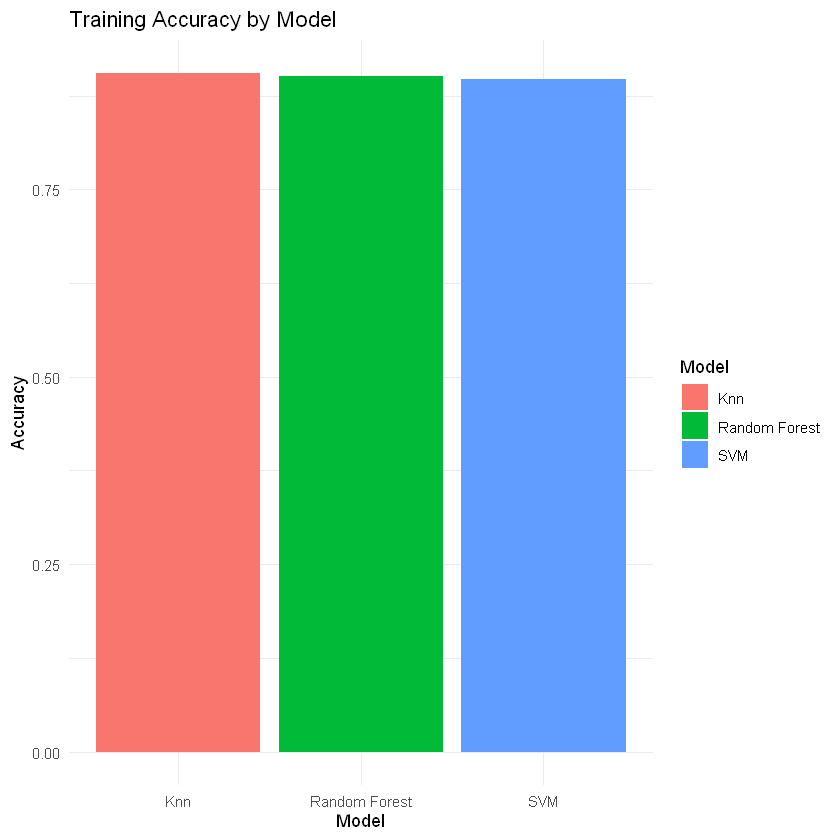

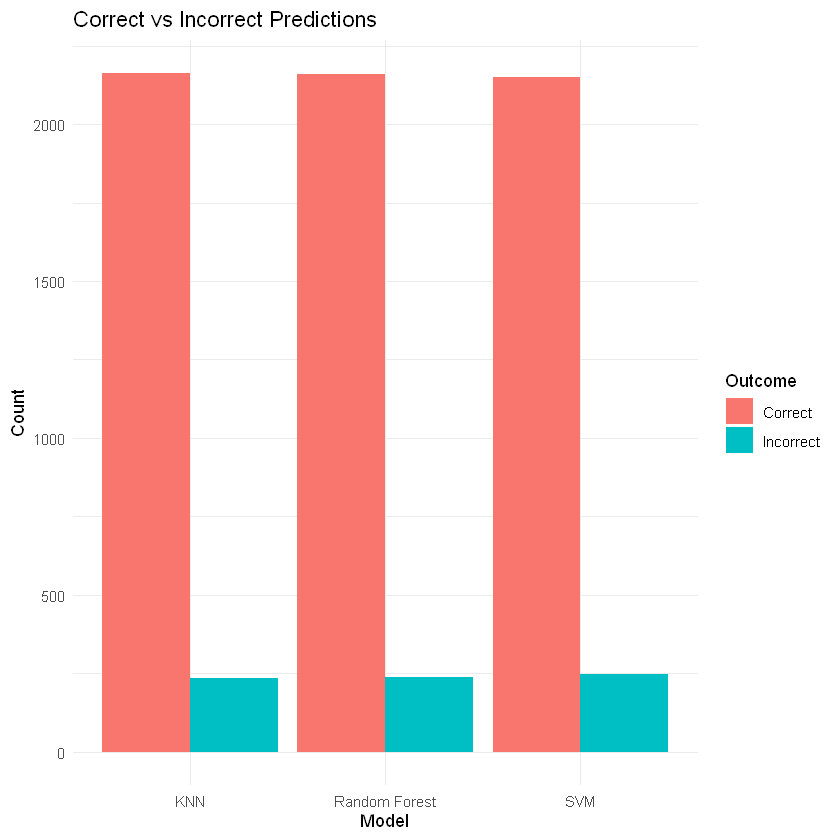

In [8]:
#generate full dataset predictions for each model
pred_rf <- predict(rf_model, X_class)
pred_knn <- predict(knn_model, X_class)
pred_svm <- predict(svm_model, X_class)

#Count the correct and incorrect predictions for Random Forest
correct_rf <- sum(pred_rf == Y_class)
incorrect_rf <- sum(pred_rf != Y_class)

#Count the correct and incorrect predictions for KNN
correct_knn <- sum(pred_knn == Y_class)
incorrect_knn <- sum(pred_knn != Y_class)

#Count the correct and incorrect predictions for SVM
correct_svm <- sum(pred_svm == Y_class)
incorrect_svm <- sum(pred_svm != Y_class)

#Build accuracy comparison table for visual
acc_df <- data.frame(
    Model = c("Random Forest", "Knn", "SVM"),
    Accuracy = c(acc_rf, acc_knn, acc_svm)
)

#Plot training accuracy for each model
ggplot(acc_df, aes(x = Model, y = Accuracy, fill = Model)) +
    geom_bar(stat="identity") +
labs(title="Training Accuracy by Model") +
theme_minimal()

#Build correct/incorrect counts for each model
ci_df <- data.frame(
    Model = rep(c("Random Forest", "KNN", "SVM"), each=2),
    Outcome = rep(c("Correct", "Incorrect"), times=3),
    Count = c(correct_rf, incorrect_rf,
              correct_knn, incorrect_knn,
              correct_svm, incorrect_svm)
)

#Plot correct vs incorrect predictions
ggplot(ci_df, aes( x = Model, y = Count, fill = Outcome)) +
    geom_bar(stat="identity", position="dodge") +
    labs(title="Correct vs Incorrect Predictions") +
    theme_minimal()